In [ ]:
from sklift.datasets import fetch_lenta
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

from catboost import CatBoostClassifier, Pool
import shap

from causalml.metrics import plot_gain, auuc_score
from causalml.inference.tree import UpliftTreeClassifier, UpliftRandomForestClassifier
from causalml.inference.meta import BaseDRClassifier, BaseRClassifier, BaseSClassifier, BaseTClassifier, BaseXClassifier
from causalml.inference.iv import BaseDRIVRegressor
import optuna

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import auc
from IPython.display import clear_output

import warnings
warnings.filterwarnings('ignore')

/Users/kolpakovaksenia/diploma/.dvenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Failed to import duecredit due to No module named 'duecredit'


In [ ]:
import sys
print(sys.executable)

/Users/kolpakovaksenia/diploma/.dvenv/bin/python


In [ ]:
SEED = 42

In [ ]:
BASE_MODEL = CatBoostClassifier(
    loss_function='Logloss',
    verbose=False,
    random_state=SEED
  )

In [ ]:
dataset = fetch_lenta()
data, target, treatment = dataset.data, dataset.target, dataset.treatment

In [ ]:
# Преобразование признака gender
data['gender'] = data['gender'].map({'Male': 1, 'Female': 0})
data['gender'] = data['gender'].fillna(-1)

In [ ]:
# Заполнение пропусков
data = data.fillna(-100)

In [ ]:
# Удаление явных дубликатов
data = data.drop_duplicates()

In [ ]:
# Разбиение на train, valid, test выборки

data['treatment'] = treatment
data['treatment'] = (data['treatment'] == 'test').astype(int)
data['target'] = target

train_val_idx, test_idx = train_test_split(data.index, test_size=0.2, random_state=SEED, stratify=data[['treatment', 'target']])

train_idx, val_idx = train_test_split(train_val_idx, test_size=0.25, random_state=SEED, stratify=data.loc[train_val_idx, ['treatment', 'target']])

X_train = data.drop(columns=['treatment', 'target']).loc[train_idx]
X_val = data.drop(columns=['treatment', 'target']).loc[val_idx]
X_test = data.drop(columns=['treatment', 'target']).loc[test_idx]

treatment_train = data['treatment'][train_idx]
treatment_val = data['treatment'][val_idx]
treatment_test = data['treatment'][test_idx]

y_train = target[train_idx]
y_val = target[val_idx]
y_test = target[test_idx]

In [ ]:
def get_uplift(model_t, model_c, X, treatment, y, selected_features):

  X_selected = X[selected_features]

  pred_c = model_c.predict_proba(X_selected)[:, 1]
  pred_t = model_t.predict_proba(X_selected)[:, 1]

  uplift_pred = pred_t - pred_c

  pred_data = pd.DataFrame({'uplift': uplift_pred,
                            'y': y,
                            'treatment': treatment})

  auuc = auuc_score(pred_data, outcome_col='y', treatment_col='treatment')
  # auuc = plot_auuc_curve(y, treatment, uplift_pred, draw_auuc=draw_auuc)

  print('AUUC:', auuc.squeeze())

  return uplift_pred, auuc

In [ ]:
def train_tlearner(base_model, X_train, treatment_train, y_train,
                   X_val, treatment_val, y_val,
                   selected_features, n_trials=50):

    X_train = pd.concat([X_train, treatment_train], axis=1)
    y_train = pd.concat([y_train, treatment_train], axis=1)

    base_params = {
        'loss_function': 'Logloss',
        'verbose': False,
        'random_state': SEED
    }

    def objective(trial):

        params_c = {
            'depth': trial.suggest_int('depth_c', 4, 10),
            'learning_rate': trial.suggest_float('learning_rate_c', 0.01, 0.3, log=True),
            'iterations': trial.suggest_int('iterations_c', 300, 1500),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg_c', 1, 20),
            'bagging_temperature': trial.suggest_float('bagging_temperature_c', 0, 10),
            'random_strength': trial.suggest_float('random_strength_c', 0, 10),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf_c', 1, 100),
        }

        params_t = {
            'depth': trial.suggest_int('depth_t', 4, 10),
            'learning_rate': trial.suggest_float('learning_rate_t', 0.01, 0.3, log=True),
            'iterations': trial.suggest_int('iterations_t', 300, 1500),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg_t', 1, 20),
            'bagging_temperature': trial.suggest_float('bagging_temperature_t', 0, 10),
            'random_strength': trial.suggest_float('random_strength_t', 0, 10),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf_t', 1, 100),
        }

        X_c = X_train[treatment_train == 0][selected_features]
        y_c = y_train[treatment_train == 0]['response_att']

        X_t = X_train[treatment_train == 1][selected_features]
        y_t = y_train[treatment_train == 1]['response_att']

        model_c = base_model.__class__(**{**params_c, **base_params})
        model_c.fit(X_c, y_c)

        model_t = base_model.__class__(**{**params_t, **base_params})
        model_t.fit(X_t, y_t)

        _, auuc_val = get_uplift(
            model_t,
            model_c,
            X_val,
            treatment_val,
            y_val,
            selected_features
        )

        return auuc_val.item()


    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, n_jobs=-1)

    best_params = study.best_params

    params_c = {
        'depth': best_params['depth_c'],
        'learning_rate': best_params['learning_rate_c'],
        'iterations': best_params['iterations_c'],
        'l2_leaf_reg': best_params['l2_leaf_reg_c'],
        'bagging_temperature': best_params['bagging_temperature_c'],
        'random_strength': best_params['random_strength_c'],
        'min_data_in_leaf': best_params['min_data_in_leaf_c'],
    }

    params_t = {
        'depth': best_params['depth_t'],
        'learning_rate': best_params['learning_rate_t'],
        'iterations': best_params['iterations_t'],
        'l2_leaf_reg': best_params['l2_leaf_reg_t'],
        'bagging_temperature': best_params['bagging_temperature_t'],
        'random_strength': best_params['random_strength_t'],
        'min_data_in_leaf': best_params['min_data_in_leaf_t'],
    }

    X_c = X_train[treatment_train == 0][selected_features]
    y_c = y_train[treatment_train == 0]['response_att']

    X_t = X_train[treatment_train == 1][selected_features]
    y_t = y_train[treatment_train == 1]['response_att']

    model_c = base_model.__class__(**{**params_c, **base_params})
    model_c.fit(X_c, y_c)

    model_t = base_model.__class__(**{**params_t, **base_params})
    model_t.fit(X_t, y_t)

    uplift_pred_train, auuc_train = get_uplift(
        model_t,
        model_c,
        X_train,
        treatment_train,
        y_train['response_att'],
        selected_features
    )

    return model_t, model_c, uplift_pred_train, auuc_train, study

### Customer feature selection from high‐dimensional bank direct marketing data for uplift modeling.

Авторы данной статьи предлагают двухстадийный подход к отбору фичей:

1. Первый этап - выделение релевантных признаков с помощью Bin-based Divergence Filters. (Из статьи Feature Selection Methods for Uplift Modeling and Heterogeneous Treatment Effect). К уже сущесствующим методам авторы предлагают еще два -
    1. UC filter - данные разбиваются на K Бинов на основе перцентилей значений признака. Для каждого Бина вычисляются - сумма значений целевой переменной в treatment группе для данного бина (фактически, количество положительных исходов в treatment); сумма значений целевой переменной в control группе для данного бина; количество наблюдений в treatment группе в данном бине;  количество наблюдений в control группе в данном бине. Итоговый score для признака F вычисляется как сумма uplift'ов по всем бинам, взвешенная на долю наблюдений в каждом бине. Высокое значение RSUC говорит о том, что признак хорошо разделяет данные на группы с разным uplift'ом. Такой признак потенциально важен для моделирования гетерогенности эффекта воздействия (CATE).
    2. AUUC filter использует параметрическую uplift-кривую для оценки важности признаков. Все наблюдения сортируются по возрастанию значения признака F. Для каждого t (количество первых наблюдений в отсортированном списке) строится точка на кривой. Функция кривой задается следующим образом: f(F_j, t) = (Y_t^T / N_t^T - Y_t^C / N_t^C) * (N_t^T + N_t^C), где Y_t^T - сумма исходов в treatment группе среди первых t наблюдений, N_t^T - количество наблюдений в treatment группе среди первых t наблюдений, Y_t^C - 	сумма исходов в control группе среди первых t наблюдений, N_t^C - количество наблюдений в control группе среди первых t наблюдений. Итоговый score для признака F - это площадь под построенной кривой. Высокое значение метрики говорит о том, что при сортировке по данному признаку, объекты с высокими значениями признака имеют систематически другой uplift, чем объекты с низкими значениями. Такой признак потенциально является хорошим модификатором эффекта воздействия.
2. Второй этап - анализ избыточности на отобранном наборе признаков. Начиная с первого по значимости признака в релевантном наборе, мы удаляем признаки с более низким рангом, коэффициент корреляции которых с ним превышает заданный параметр 𝜌₀. В данной работе параметр 𝜌₀ установлен равным 0.8.

Из библиотеки upliftml возьмем метод UpliftCurveFilter, он соотвествует второму предложенному в статье методу оценки признаков с помощью uplift-кривой:

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import auc

def rsaauuc_single_feature(
    x: pd.Series,
    treatment: pd.Series,
    y: pd.Series,
    n_bins=10
):
    df = pd.DataFrame({
        'x': x,
        'treatment': treatment,
        'y': y
    }).dropna()

    if df['x'].nunique() < 3:
        return 0.0

    try:
        df = df.sort_values('x')
        df['bin'] = pd.qcut(df['x'], q=n_bins, duplicates='drop')
    except ValueError:
        return 0.0

    uplift_values = []

    for _, group in df.groupby('bin', observed=True):
        yt = group.loc[group.treatment == 1, 'y']
        yc = group.loc[group.treatment == 0, 'y']

        if len(yt) < 5 or len(yc) < 5:
            continue

        uplift_values.append(yt.mean() - yc.mean())

    if len(uplift_values) < 2:
        return 0.0

    return auc(np.arange(len(uplift_values)), uplift_values)

In [ ]:
from tqdm import tqdm


def rsaauuc_feature_ranking(
    X: pd.DataFrame,
    treatment: pd.Series,
    y: pd.Series,
    n_bins=10
):
    scores = {}

    for col in tqdm(X.columns):
        scores[col] = rsaauuc_single_feature(
            X[col], treatment, y, n_bins=n_bins
        )

    return (
        pd.Series(scores)
        .sort_values(ascending=False)
    )

In [ ]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform


def redundancy_reduction(
    X: pd.DataFrame,
    scores: pd.Series,
    top_k=80,
    corr_threshold=0.85
):
    top_feats = scores.head(top_k).index.tolist()

    corr = X[top_feats].corr().abs()

    dist = 1 - corr
    condensed = squareform(dist.values)

    Z = linkage(condensed, method='average')

    clusters = fcluster(Z, t=1 - corr_threshold, criterion='distance')

    cluster_df = pd.DataFrame({
        'feature': top_feats,
        'cluster': clusters,
        'score': scores.loc[top_feats].values
    })

    selected = (
        cluster_df
        .sort_values('score', ascending=False)
        .groupby('cluster')
        .head(1)['feature']
        .tolist()
    )

    return selected, cluster_df

In [ ]:
def get_features(
    X, treatment, y,
    n_bins=10,
    top_k=80,
    corr_threshold=0.80
):
    scores = rsaauuc_feature_ranking(
        X, treatment, y, n_bins=n_bins
    )

    selected, cluster_df = redundancy_reduction(
        X, scores,
        top_k=top_k,
        corr_threshold=corr_threshold
    )

    return selected, scores, cluster_df

In [ ]:
 selected_features_v1, scores_v1, cluster_df_v1 = get_features(X_train, treatment_train, y_train)

100%|█████████████████████████████████████████| 193/193 [00:06<00:00, 32.04it/s]


In [ ]:
len(selected_features_v1)

48

In [ ]:
model_t_v1, model_c_v1, uplift_pred_train_v1, auuc_train_v1, study_v1 = train_tlearner(BASE_MODEL, X_train, treatment_train, y_train,
                                                                             X_val, treatment_val, y_val,
                                                                             selected_features_v1)

[I 2026-03-09 22:48:17,892] A new study created in memory with name: no-name-9aebe668-eb87-4341-bbf7-fa906150a2fc
[I 2026-03-09 22:49:06,626] Trial 2 finished with value: 0.4275918574067123 and parameters: {'depth_c': 6, 'learning_rate_c': 0.16110336058831376, 'iterations_c': 502, 'l2_leaf_reg_c': 7.138077319265809, 'bagging_temperature_c': 4.739457139914002, 'random_strength_c': 1.7006259810301128, 'min_data_in_leaf_c': 25, 'depth_t': 4, 'learning_rate_t': 0.03499385638468663, 'iterations_t': 462, 'l2_leaf_reg_t': 1.2547339388610588, 'bagging_temperature_t': 1.8932544970701137, 'random_strength_t': 9.409570903631764, 'min_data_in_leaf_t': 3}. Best is trial 2 with value: 0.4275918574067123.


AUUC: 0.4275918574067123


[I 2026-03-09 22:49:29,824] Trial 11 finished with value: 0.5340388634689909 and parameters: {'depth_c': 7, 'learning_rate_c': 0.03108231290420441, 'iterations_c': 463, 'l2_leaf_reg_c': 1.3237892037719097, 'bagging_temperature_c': 4.291498695584403, 'random_strength_c': 3.6377313693771542, 'min_data_in_leaf_c': 87, 'depth_t': 4, 'learning_rate_t': 0.29223038301595644, 'iterations_t': 731, 'l2_leaf_reg_t': 1.823257584897128, 'bagging_temperature_t': 7.533260648927888, 'random_strength_t': 3.1621194614775385, 'min_data_in_leaf_t': 20}. Best is trial 11 with value: 0.5340388634689909.


AUUC: 0.5340388634689909


[I 2026-03-09 22:49:33,842] Trial 13 finished with value: 0.5956130640961075 and parameters: {'depth_c': 5, 'learning_rate_c': 0.015429639753646742, 'iterations_c': 729, 'l2_leaf_reg_c': 13.565551066248753, 'bagging_temperature_c': 8.259042974869372, 'random_strength_c': 2.2967900009223143, 'min_data_in_leaf_c': 76, 'depth_t': 4, 'learning_rate_t': 0.014290078605905027, 'iterations_t': 749, 'l2_leaf_reg_t': 1.1861208454190955, 'bagging_temperature_t': 7.6446967443039355, 'random_strength_t': 6.7291413891994925, 'min_data_in_leaf_t': 59}. Best is trial 13 with value: 0.5956130640961075.


...

AUUC: 0.6356423341927715


[I 2026-03-09 23:06:05,528] Trial 47 finished with value: 0.5560538083543506 and parameters: {'depth_c': 9, 'learning_rate_c': 0.028471427374865074, 'iterations_c': 1369, 'l2_leaf_reg_c': 9.329629477545472, 'bagging_temperature_c': 6.036827928976306, 'random_strength_c': 7.651440629608781, 'min_data_in_leaf_c': 27, 'depth_t': 8, 'learning_rate_t': 0.042695496592369576, 'iterations_t': 984, 'l2_leaf_reg_t': 16.592280768374177, 'bagging_temperature_t': 1.472803606026147, 'random_strength_t': 2.224438327281285, 'min_data_in_leaf_t': 83}. Best is trial 26 with value: 0.7665243532617886.


AUUC: 0.5560538083543506


[I 2026-03-09 23:06:08,462] Trial 49 finished with value: 0.615852631719415 and parameters: {'depth_c': 9, 'learning_rate_c': 0.02249906626059799, 'iterations_c': 1190, 'l2_leaf_reg_c': 9.739488513721422, 'bagging_temperature_c': 6.399460335004081, 'random_strength_c': 4.094563845848668, 'min_data_in_leaf_c': 28, 'depth_t': 8, 'learning_rate_t': 0.019671243425294724, 'iterations_t': 1010, 'l2_leaf_reg_t': 16.33368344606691, 'bagging_temperature_t': 5.555842971236071, 'random_strength_t': 2.344338670227827, 'min_data_in_leaf_t': 13}. Best is trial 26 with value: 0.7665243532617886.


AUUC: 0.615852631719415
AUUC: 6.7274703088045325


In [ ]:
uplift_pred_test_v1, auuc_test_v1 = get_uplift(model_t_v1, model_c_v1, X_test, treatment_test, y_test, selected_features_v1)

AUUC: 0.7394552600334697


In [ ]:
# 0.5764277840921775 - до оптуны

### Doubly Robust Adaptive LASSO for Effect

In [ ]:
from catboost import CatBoostRegressor, CatBoostClassifier


def train_nuisance_models(X, T, y):
    mu1 = CatBoostRegressor(verbose=False, random_state=SEED)
    mu0 = CatBoostRegressor(verbose=False, random_state=SEED)
    e = CatBoostClassifier(verbose=False, random_state=SEED)

    mu1.fit(X[T==1], y[T==1])
    mu0.fit(X[T==0], y[T==0])
    e.fit(X, T)

    return mu1, mu0, e

In [ ]:
def compute_dr_pseudo_outcome(X, T, y, mu1, mu0, e):
    mu1_pred = mu1.predict(X)
    mu0_pred = mu0.predict(X)
    e_pred = np.clip(e.predict_proba(X)[:,1], 1e-3, 1-1e-3)

    tau_hat = (
        T * (y - mu1_pred) / e_pred
        - (1-T) * (y - mu0_pred) / (1 - e_pred)
        + mu1_pred - mu0_pred
    )

    return tau_hat

In [ ]:
from sklearn.linear_model import Ridge

def initial_ridge_weights(X, tau_hat):
    ridge = Ridge(alpha=1.0, random_state=SEED)
    ridge.fit(X, tau_hat)
    return np.abs(ridge.coef_)

In [ ]:
from sklearn.linear_model import Lasso

def adaptive_lasso(X, tau_hat, weights, alpha=0.01):
    X_scaled = X / (weights + 1e-6)

    lasso = Lasso(alpha=alpha, random_state=SEED)
    lasso.fit(X_scaled, tau_hat)

    beta = lasso.coef_ / (weights + 1e-6)

    return beta


In [ ]:
def dr_adaptive_lasso_feature_selection(
    X, T, y,
    alpha=0.01
):
    mu1, mu0, e = train_nuisance_models(X, T, y)

    tau_hat = compute_dr_pseudo_outcome(X, T, y, mu1, mu0, e)

    weights = initial_ridge_weights(X, tau_hat)

    beta = adaptive_lasso(X, tau_hat, weights, alpha)

    selected_features = X.columns[np.abs(beta) > 1e-6].tolist()

    return selected_features, beta, tau_hat


In [ ]:
selected_features_v2, beta, tau_hat = dr_adaptive_lasso_feature_selection(X_train, treatment_train, y_train, alpha=0.001)

In [ ]:
len(selected_features_v2)

184

In [ ]:
model_t_v2, model_c_v2, uplift_pred_train_v2, auuc_train_v2, study_v2 = train_tlearner(BASE_MODEL, 
                                                                                       X_train, 
                                                                                       treatment_train, 
                                                                                       y_train, 
                                                                                       X_val, 
                                                                                       treatment_val, 
                                                                                       y_val, 
                                                                                       selected_features_v2)

[I 2026-03-09 23:08:27,883] A new study created in memory with name: no-name-17015ba2-4772-4248-9d05-5924e1c8d302
[I 2026-03-09 23:12:29,653] Trial 12 finished with value: 0.5962632461651463 and parameters: {'depth_c': 6, 'learning_rate_c': 0.05089701936493148, 'iterations_c': 738, 'l2_leaf_reg_c': 16.49455979982744, 'bagging_temperature_c': 7.0104482951409794, 'random_strength_c': 5.096065708521794, 'min_data_in_leaf_c': 2, 'depth_t': 8, 'learning_rate_t': 0.02071793502253297, 'iterations_t': 450, 'l2_leaf_reg_t': 11.516565480006884, 'bagging_temperature_t': 8.504856565323754, 'random_strength_t': 9.858538793590139, 'min_data_in_leaf_t': 84}. Best is trial 12 with value: 0.5962632461651463.


AUUC: 0.5962632461651463


[I 2026-03-09 23:12:36,447] Trial 5 finished with value: 0.6083926170075526 and parameters: {'depth_c': 8, 'learning_rate_c': 0.046229438983325356, 'iterations_c': 356, 'l2_leaf_reg_c': 2.5751852688665027, 'bagging_temperature_c': 8.00726546850939, 'random_strength_c': 1.1894700498394895, 'min_data_in_leaf_c': 10, 'depth_t': 4, 'learning_rate_t': 0.013951573712018155, 'iterations_t': 860, 'l2_leaf_reg_t': 3.9064342254672795, 'bagging_temperature_t': 2.832603750592202, 'random_strength_t': 3.2913796874202808, 'min_data_in_leaf_t': 48}. Best is trial 5 with value: 0.6083926170075526.


AUUC: 0.6083926170075526


[I 2026-03-09 23:12:58,940] Trial 6 finished with value: 0.568440931366672 and parameters: {'depth_c': 7, 'learning_rate_c': 0.03856671873123997, 'iterations_c': 474, 'l2_leaf_reg_c': 13.224101710666037, 'bagging_temperature_c': 2.7348434708817884, 'random_strength_c': 0.1901577997912074, 'min_data_in_leaf_c': 55, 'depth_t': 7, 'learning_rate_t': 0.059627001657843744, 'iterations_t': 700, 'l2_leaf_reg_t': 8.715904231622174, 'bagging_temperature_t': 3.9485685084061783, 'random_strength_t': 2.2195984805224, 'min_data_in_leaf_t': 60}. Best is trial 5 with value: 0.6083926170075526.


...

AUUC: 0.5570210970303014


[I 2026-03-09 23:57:59,894] Trial 29 finished with value: 0.717339488798904 and parameters: {'depth_c': 10, 'learning_rate_c': 0.11572701977717235, 'iterations_c': 1487, 'l2_leaf_reg_c': 5.201212259921324, 'bagging_temperature_c': 1.7609450741231254, 'random_strength_c': 6.282598268206059, 'min_data_in_leaf_c': 79, 'depth_t': 10, 'learning_rate_t': 0.016905147464010783, 'iterations_t': 1467, 'l2_leaf_reg_t': 8.703540376611908, 'bagging_temperature_t': 6.587553111064265, 'random_strength_t': 5.9225976362533626, 'min_data_in_leaf_t': 31}. Best is trial 48 with value: 0.7758832040174407.


AUUC: 0.717339488798904


[I 2026-03-09 23:58:01,848] Trial 31 finished with value: 0.6495860351563801 and parameters: {'depth_c': 10, 'learning_rate_c': 0.13126963501840466, 'iterations_c': 1449, 'l2_leaf_reg_c': 9.9639423496754, 'bagging_temperature_c': 1.623385122201581, 'random_strength_c': 6.720888964183514, 'min_data_in_leaf_c': 77, 'depth_t': 10, 'learning_rate_t': 0.016604638599152746, 'iterations_t': 1487, 'l2_leaf_reg_t': 8.199168718258331, 'bagging_temperature_t': 9.577571989169108, 'random_strength_t': 5.573003051226563, 'min_data_in_leaf_t': 35}. Best is trial 48 with value: 0.7758832040174407.


AUUC: 0.6495860351563801
AUUC: 6.740784380849549


In [ ]:
uplift_pred_test_v2, auuc_test_v2 = get_uplift(model_t_v2, model_c_v2, X_test, treatment_test, y_test, 
                                               selected_features_v2)

AUUC: 0.48795175481147396


In [ ]:
# до оптуны метрика была выше - 0.6668880309490919

### A Non-parametric Bayesian Approach for Uplift Discretization and Feature Selection

Код реализован в библиотеке kuplift - https://github.com/UData-Orange/kuplift/blob/main/kuplift/feature_selection.py

Для ускорения работы отберем признаки на валидационной выборке

In [ ]:
import kuplift as kp

In [ ]:
fs = kp.FeatureSelection()

important_vars = fs.filter(
    X_val,
    treatment_val,
    y_val
)

In [ ]:
important_vars

{'gender': 0,
 'promo_share_15d': 3.485882970737384e-05,
 'k_var_sku_price_1m_g26': 3.969220190779956e-05,
 'k_var_sku_price_3m_g24': 3.973858593423515e-05,
 'mean_discount_depth_15d': 4.0548634555479084e-05,
 'sale_sum_12m_g26': 4.297170548488893e-05,
 'k_var_sku_price_1m_g54': 4.331536845124712e-05,
 'disc_sum_6m_g34': 4.3543643487371094e-05,
 'k_var_sku_price_3m_g33': 4.428677536220568e-05,
 'k_var_disc_share_1m_g49': 4.5032289431259245e-05,
 'k_var_count_per_cheque_3m_g24': 4.582397830270521e-05,
 'sale_sum_3m_g33': 4.59610954334403e-05,
 'k_var_count_per_cheque_6m_g24': 4.604826990506511e-05,
 'k_var_sku_price_1m_g40': 4.730351463399946e-05,
 'k_var_count_per_cheque_15d_g34': 4.7396768259551914e-05,
 'k_var_sku_price_6m_g41': 4.7548803476762865e-05,
 'sale_count_6m_g32': 4.755212611006628e-05,
 'k_var_sku_price_3m_g54': 4.779033158926403e-05,
 'k_var_sku_price_3m_g32': 4.80703186608137e-05,
 'k_var_cheque_15d': 4.8244707873699545e-05,
 'k_var_sku_price_1m_g49': 4.854045578555415e-

In [ ]:
len(important_vars)

193

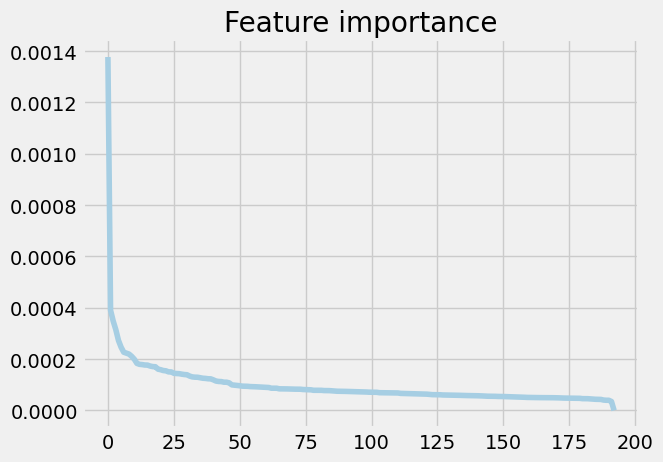

In [ ]:
scores = sorted(important_vars.values(), reverse=True)

plt.plot(scores)
plt.title('Feature importance')
plt.show()

In [ ]:
def find_elbow(scores_dict):
    scores = np.array(sorted(scores_dict.values(), reverse=True))

    x = np.arange(len(scores))
    y = scores

    line_start = np.array([0, y[0]])
    line_end = np.array([len(scores)-1, y[-1]])

    line_vec = line_end - line_start
    line_vec_norm = line_vec / np.linalg.norm(line_vec)

    distances = []
    for i in range(len(scores)):
        point = np.array([i, y[i]])
        vec = point - line_start
        proj = np.dot(vec, line_vec_norm) * line_vec_norm
        dist = np.linalg.norm(vec - proj)
        distances.append(dist)

    elbow_idx = np.argmax(distances)
    return elbow_idx + 1

optimal_features = find_elbow(important_vars)
print(f'Оптимальное количество признаков по локтю: {optimal_features}')

Оптимальное количество признаков по локтю: 12


In [ ]:
scores_series = pd.Series(important_vars).sort_values(ascending=False)
top_features = scores_series.head(optimal_features).index.tolist()

In [ ]:
top_features

['perdelta_days_between_visits_15_30d',
 'cheque_count_6m_g25',
 'k_var_cheque_group_width_15d',
 'k_var_days_between_visits_15d',
 'sale_count_12m_g49',
 'cheque_count_6m_g32',
 'sale_count_12m_g54',
 'response_sms',
 'cheque_count_6m_g20',
 'cheque_count_12m_g57',
 'k_var_count_per_cheque_6m_g44',
 'crazy_purchases_cheque_count_12m']

In [ ]:
model_t_v3, model_c_v3, uplift_pred_train_v3, auuc_train_v3, study = train_tlearner(BASE_MODEL, X_train, treatment_train, y_train, 
                                                                             X_val, treatment_val, y_val, 
                                                                             top_features)

[I 2026-03-10 00:26:06,841] A new study created in memory with name: no-name-7520e4cb-a89b-4ec8-a250-8b116b781f64
[I 2026-03-10 00:26:47,886] Trial 1 finished with value: 0.3489808641142178 and parameters: {'depth_c': 7, 'learning_rate_c': 0.013377676761139061, 'iterations_c': 570, 'l2_leaf_reg_c': 7.873608596061299, 'bagging_temperature_c': 4.741368224339199, 'random_strength_c': 6.687912973612576, 'min_data_in_leaf_c': 32, 'depth_t': 8, 'learning_rate_t': 0.2292758500877969, 'iterations_t': 402, 'l2_leaf_reg_t': 13.245074314756184, 'bagging_temperature_t': 2.0009871783287183, 'random_strength_t': 0.6938436229663059, 'min_data_in_leaf_t': 41}. Best is trial 1 with value: 0.3489808641142178.


AUUC: 0.3489808641142178


[I 2026-03-10 00:26:50,689] Trial 7 finished with value: 0.675943215535098 and parameters: {'depth_c': 4, 'learning_rate_c': 0.03572530453146523, 'iterations_c': 367, 'l2_leaf_reg_c': 8.20497910363088, 'bagging_temperature_c': 3.1223238823824353, 'random_strength_c': 5.156806808353364, 'min_data_in_leaf_c': 61, 'depth_t': 9, 'learning_rate_t': 0.02483260058013546, 'iterations_t': 482, 'l2_leaf_reg_t': 15.875800399001418, 'bagging_temperature_t': 9.363164715301176, 'random_strength_t': 9.031769799456704, 'min_data_in_leaf_t': 17}. Best is trial 7 with value: 0.675943215535098.


AUUC: 0.675943215535098


[I 2026-03-10 00:26:51,408] Trial 0 finished with value: 0.6940696706424407 and parameters: {'depth_c': 8, 'learning_rate_c': 0.014729585695159288, 'iterations_c': 834, 'l2_leaf_reg_c': 9.035522240935752, 'bagging_temperature_c': 4.771674957582767, 'random_strength_c': 3.9171218604822657, 'min_data_in_leaf_c': 43, 'depth_t': 5, 'learning_rate_t': 0.026103292130616098, 'iterations_t': 384, 'l2_leaf_reg_t': 13.402591623487295, 'bagging_temperature_t': 8.376013067983548, 'random_strength_t': 0.189763847183666, 'min_data_in_leaf_t': 71}. Best is trial 0 with value: 0.6940696706424407.


...

AUUC: 0.6780207429274675


[I 2026-03-10 00:31:39,503] Trial 40 finished with value: 0.6492178348170208 and parameters: {'depth_c': 10, 'learning_rate_c': 0.2672008402481189, 'iterations_c': 811, 'l2_leaf_reg_c': 10.094130509120207, 'bagging_temperature_c': 2.7387418988660346, 'random_strength_c': 1.6539925957758959, 'min_data_in_leaf_c': 40, 'depth_t': 5, 'learning_rate_t': 0.05133119101951682, 'iterations_t': 1009, 'l2_leaf_reg_t': 1.0362596005476625, 'bagging_temperature_t': 7.578094083378518, 'random_strength_t': 5.322163241364098, 'min_data_in_leaf_t': 35}. Best is trial 48 with value: 0.7352300119374944.
[I 2026-03-10 00:31:39,543] Trial 41 finished with value: 0.6389137677093464 and parameters: {'depth_c': 10, 'learning_rate_c': 0.29753751349518703, 'iterations_c': 792, 'l2_leaf_reg_c': 9.969785860962283, 'bagging_temperature_c': 0.24410398184584237, 'random_strength_c': 4.072800852982597, 'min_data_in_leaf_c': 41, 'depth_t': 5, 'learning_rate_t': 0.04894332256272142, 'iterations_t': 1001, 'l2_leaf_reg_t'

AUUC: 0.6492178348170208
AUUC: 0.6389137677093464


[I 2026-03-10 00:31:40,272] Trial 31 finished with value: 0.5245568405182465 and parameters: {'depth_c': 6, 'learning_rate_c': 0.03786538440063815, 'iterations_c': 934, 'l2_leaf_reg_c': 7.558653973784345, 'bagging_temperature_c': 1.8777605157122939, 'random_strength_c': 2.116392482061231, 'min_data_in_leaf_c': 66, 'depth_t': 10, 'learning_rate_t': 0.02632712941850384, 'iterations_t': 1439, 'l2_leaf_reg_t': 11.05660631325287, 'bagging_temperature_t': 9.679098613177818, 'random_strength_t': 9.765496132200825, 'min_data_in_leaf_t': 79}. Best is trial 48 with value: 0.7352300119374944.


AUUC: 0.5245568405182465
AUUC: 7.026426259180391


In [ ]:
uplift_pred_test_v3, auuc_test_v3 = get_uplift(model_t_v3, model_c_v3, X_test, treatment_test, y_test, top_features)

AUUC: 0.8060838140308804


In [ ]:
# попробуем взять топ-50 фичей
top_features_v2 = scores_series.head(50).index.tolist()
model_t_v4, model_c_v4, uplift_pred_train_v4, auuc_train_v4, study = train_tlearner(BASE_MODEL, X_train, treatment_train, y_train, 
                                                                             X_val, treatment_val, y_val, 
                                                                             top_features_v2)

[I 2026-03-10 00:31:50,692] A new study created in memory with name: no-name-5e577db2-812a-4e61-b747-11f3bf725fc1
[I 2026-03-10 00:33:41,587] Trial 11 finished with value: 0.6465665687080158 and parameters: {'depth_c': 8, 'learning_rate_c': 0.01471966502983872, 'iterations_c': 891, 'l2_leaf_reg_c': 13.9301575104296, 'bagging_temperature_c': 2.293853826493196, 'random_strength_c': 2.5821116400415245, 'min_data_in_leaf_c': 50, 'depth_t': 5, 'learning_rate_t': 0.021686889542431642, 'iterations_t': 417, 'l2_leaf_reg_t': 15.70761470754583, 'bagging_temperature_t': 5.247397565756435, 'random_strength_t': 5.476912898229478, 'min_data_in_leaf_t': 92}. Best is trial 11 with value: 0.6465665687080158.


AUUC: 0.6465665687080158


[I 2026-03-10 00:33:50,242] Trial 4 finished with value: 0.6696999696599067 and parameters: {'depth_c': 5, 'learning_rate_c': 0.284410849985758, 'iterations_c': 628, 'l2_leaf_reg_c': 8.76073546690961, 'bagging_temperature_c': 5.353485095044932, 'random_strength_c': 0.40775819685908266, 'min_data_in_leaf_c': 6, 'depth_t': 4, 'learning_rate_t': 0.010869918894907663, 'iterations_t': 836, 'l2_leaf_reg_t': 6.561039430622176, 'bagging_temperature_t': 1.9254044482662536, 'random_strength_t': 0.2206855992874457, 'min_data_in_leaf_t': 88}. Best is trial 4 with value: 0.6696999696599067.


AUUC: 0.6696999696599067


[I 2026-03-10 00:34:08,739] Trial 13 finished with value: 0.5573709478487525 and parameters: {'depth_c': 7, 'learning_rate_c': 0.04034915638987302, 'iterations_c': 634, 'l2_leaf_reg_c': 15.954907141678031, 'bagging_temperature_c': 4.2177552854178195, 'random_strength_c': 8.14101460778363, 'min_data_in_leaf_c': 89, 'depth_t': 9, 'learning_rate_t': 0.03025156991594426, 'iterations_t': 559, 'l2_leaf_reg_t': 3.8406697145302977, 'bagging_temperature_t': 8.263078885403202, 'random_strength_t': 4.969432503187717, 'min_data_in_leaf_t': 69}. Best is trial 4 with value: 0.6696999696599067.


...

AUUC: 0.7835498118481421


[I 2026-03-10 00:43:43,896] Trial 46 finished with value: 0.6362249317675444 and parameters: {'depth_c': 8, 'learning_rate_c': 0.048144851581571176, 'iterations_c': 1329, 'l2_leaf_reg_c': 10.34175671208644, 'bagging_temperature_c': 6.979226440075574, 'random_strength_c': 7.23895594430638, 'min_data_in_leaf_c': 61, 'depth_t': 6, 'learning_rate_t': 0.06262751928794014, 'iterations_t': 532, 'l2_leaf_reg_t': 14.718458347603864, 'bagging_temperature_t': 4.2878104332834415, 'random_strength_t': 8.783117002593073, 'min_data_in_leaf_t': 77}. Best is trial 45 with value: 0.7835498118481421.


AUUC: 0.6362249317675444


[I 2026-03-10 00:43:48,137] Trial 48 finished with value: 0.7375566980877687 and parameters: {'depth_c': 5, 'learning_rate_c': 0.04743466588605471, 'iterations_c': 1173, 'l2_leaf_reg_c': 13.00644445861191, 'bagging_temperature_c': 0.1410574239832044, 'random_strength_c': 7.5383561405479735, 'min_data_in_leaf_c': 61, 'depth_t': 6, 'learning_rate_t': 0.017194019675484565, 'iterations_t': 1207, 'l2_leaf_reg_t': 18.345361961628736, 'bagging_temperature_t': 6.502671048710594, 'random_strength_t': 9.091365322540309, 'min_data_in_leaf_t': 37}. Best is trial 45 with value: 0.7835498118481421.


AUUC: 0.7375566980877687
AUUC: 5.96606643643768


In [ ]:
uplift_pred_test_v4, auuc_test_v4 = get_uplift(model_t_v4, model_c_v4, X_test, treatment_test, y_test, top_features_v2)

AUUC: 0.46190517883929855


### Robustness-enhanced Uplift Modeling with Adversarial Feature Desensitization

In [ ]:
class RUAD_AUUC_Selector:
    def __init__(self, hidden_dim=128, epochs=50, lr=1e-3, top_k=30, device='cpu'):
        
        self.hidden_dim = hidden_dim
        self.epochs = epochs
        self.lr = lr
        self.top_k = top_k
        self.device = device

    def _create_joint_label(self, t, y):
        
        return t * 2 + y

    def _compute_uplift(self, probs):
  
        p_y1_t0 = probs[:,1] / (probs[:,0]+probs[:,1]+1e-8)
        p_y1_t1 = probs[:,3] / (probs[:,2]+probs[:,3]+1e-8)
        tau_hat = p_y1_t1 - p_y1_t0
        return tau_hat

    def _auuc_per_feature(self, X, uplift):
        
        N, d = X.shape
        scores = []
        for i in range(d):
            order = np.argsort(X[:,i])
            uplift_sorted = uplift[order]
            if len(uplift_sorted) < 2:
                scores.append(0)
            else:
                scores.append(auc(np.arange(len(uplift_sorted)), uplift_sorted))
        return np.array(scores)

    def fit(self, X_train, t_train, y_train, X_val, t_val, y_val):
        
        if isinstance(X_train, pd.DataFrame):
            self.feature_names = X_train.columns
            X_train_np = X_train.values
            X_val_np = X_val.values
        else:
            self.feature_names = np.arange(X_train.shape[1])
            X_train_np = X_train
            X_val_np = X_val

        d = X_train_np.shape[1]

        X_tensor = torch.tensor(X_train_np, dtype=torch.float32).to(self.device)
        y_tensor = torch.tensor(self._create_joint_label(t_train, y_train), dtype=torch.long).to(self.device)

        self.model = nn.Sequential(
            nn.Linear(d, self.hidden_dim),
            nn.ReLU(),
            nn.Linear(self.hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 4)
        ).to(self.device)

        optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr)
        criterion = nn.CrossEntropyLoss()

        losses = []
        auuc_history = []

        for epoch in range(self.epochs):
    
            logits = self.model(X_tensor)
            loss = criterion(logits, y_tensor)
            losses.append(loss.item())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                probs_val = torch.softmax(self.model(torch.tensor(X_val_np, dtype=torch.float32).to(self.device)), dim=1).cpu().numpy()
            
            uplift_val = self._compute_uplift(probs_val)
            auuc_epoch = self._auuc_per_feature(X_val_np, uplift_val)
            auuc_history.append(auuc_epoch)

            clear_output(wait=True)
            plt.figure(figsize=(6,4))
            plt.plot(range(1, len(losses)+1), losses, marker='o')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.title('RUAD Training Loss')
            plt.grid(True)
            plt.show()

        self.importance_ = np.mean(auuc_history, axis=0)
        idx = np.argsort(self.importance_)[-self.top_k:]
        self.selected_idx_ = idx
        self.selected_features_ = self.feature_names[idx]

        return self

    def transform(self, X):
        
        if isinstance(X, pd.DataFrame):
            return X[self.selected_features_]
        return X[:, self.selected_idx_]
    
    def fit_transform(self, X_train, t_train, y_train, X_val, t_val, y_val):
        
        self.fit(X_train, t_train, y_train, X_val, t_val, y_val)
        return self.transform(X_train)

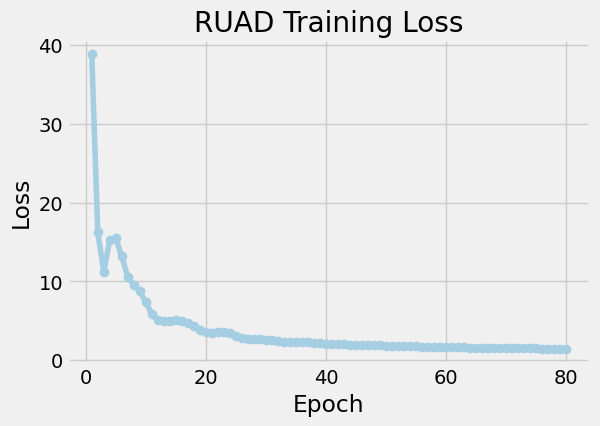

In [ ]:
selector = RUAD_AUUC_Selector(hidden_dim=128, epochs=80, lr=1e-3, top_k=50)
X_selected = selector.fit_transform(X_train, treatment_train, y_train, X_val, treatment_val, y_val)

In [ ]:
print('Число отобранных признако:', len(selector.selected_features_))

Число отобранных признако: 50


In [ ]:
selected_features_v5 = X_selected.columns.tolist()

In [ ]:
model_t_v5, model_c_v5, uplift_pred_train_v5, auuc_train_v5, study = train_tlearner(BASE_MODEL, X_train, treatment_train, y_train, 
                                                                             X_val, treatment_val, y_val, 
                                                                             selected_features_v5)

[I 2026-03-10 07:23:21,416] A new study created in memory with name: no-name-e11e30c6-0726-4a5b-a597-43aba49274bd
[I 2026-03-10 07:24:22,342] Trial 10 finished with value: 0.4689065322102958 and parameters: {'depth_c': 4, 'learning_rate_c': 0.054938131566231486, 'iterations_c': 753, 'l2_leaf_reg_c': 11.259116237703886, 'bagging_temperature_c': 6.500889387917722, 'random_strength_c': 6.581087022288533, 'min_data_in_leaf_c': 10, 'depth_t': 8, 'learning_rate_t': 0.07971351777057996, 'iterations_t': 312, 'l2_leaf_reg_t': 18.229654605231133, 'bagging_temperature_t': 2.8687295339674037, 'random_strength_t': 9.309221069844542, 'min_data_in_leaf_t': 94}. Best is trial 10 with value: 0.4689065322102958.


AUUC: 0.4689065322102958


[I 2026-03-10 07:24:38,576] Trial 4 finished with value: 0.6194479267235771 and parameters: {'depth_c': 4, 'learning_rate_c': 0.2467320546568183, 'iterations_c': 1110, 'l2_leaf_reg_c': 5.827077817141831, 'bagging_temperature_c': 8.370780185291114, 'random_strength_c': 7.870541111623219, 'min_data_in_leaf_c': 85, 'depth_t': 5, 'learning_rate_t': 0.11680616052407733, 'iterations_t': 470, 'l2_leaf_reg_t': 1.0729683032028365, 'bagging_temperature_t': 9.349590098785066, 'random_strength_t': 1.6171233894404402, 'min_data_in_leaf_t': 89}. Best is trial 4 with value: 0.6194479267235771.


AUUC: 0.6194479267235771


[I 2026-03-10 07:25:04,363] Trial 13 finished with value: 0.38512684245618006 and parameters: {'depth_c': 6, 'learning_rate_c': 0.0344886744687507, 'iterations_c': 573, 'l2_leaf_reg_c': 2.3813855806489688, 'bagging_temperature_c': 6.824923476250758, 'random_strength_c': 9.444637755060475, 'min_data_in_leaf_c': 53, 'depth_t': 8, 'learning_rate_t': 0.14472990855338877, 'iterations_t': 681, 'l2_leaf_reg_t': 18.595902792308998, 'bagging_temperature_t': 6.981210766397384, 'random_strength_t': 8.676174960291824, 'min_data_in_leaf_t': 55}. Best is trial 4 with value: 0.6194479267235771.


...

AUUC: 0.6423784353575533
AUUC: 0.6903854652964758


[I 2026-03-10 07:35:00,115] Trial 49 finished with value: 0.5465542490173716 and parameters: {'depth_c': 9, 'learning_rate_c': 0.013391317523341268, 'iterations_c': 419, 'l2_leaf_reg_c': 17.46216786114382, 'bagging_temperature_c': 3.0898489968512375, 'random_strength_c': 5.51600564749125, 'min_data_in_leaf_c': 65, 'depth_t': 5, 'learning_rate_t': 0.018558850411135943, 'iterations_t': 1205, 'l2_leaf_reg_t': 6.848578917260242, 'bagging_temperature_t': 2.513872045033683, 'random_strength_t': 2.1386053204355484, 'min_data_in_leaf_t': 62}. Best is trial 32 with value: 0.758657274821487.


AUUC: 0.5465542490173716


[I 2026-03-10 07:35:01,616] Trial 48 finished with value: 0.5114608853654922 and parameters: {'depth_c': 9, 'learning_rate_c': 0.01313389237552756, 'iterations_c': 445, 'l2_leaf_reg_c': 17.9824994231045, 'bagging_temperature_c': 2.95550842107882, 'random_strength_c': 5.678461829381633, 'min_data_in_leaf_c': 63, 'depth_t': 5, 'learning_rate_t': 0.01902480135224568, 'iterations_t': 1260, 'l2_leaf_reg_t': 6.952749829083473, 'bagging_temperature_t': 2.347008028466993, 'random_strength_t': 2.303091987758896, 'min_data_in_leaf_t': 64}. Best is trial 32 with value: 0.758657274821487.


AUUC: 0.5114608853654922
AUUC: 2.611112980020855


In [ ]:
uplift_pred_test_v5, auuc_test_v5 = get_uplift(model_t_v5, model_c_v5, X_test, treatment_test, y_test, selected_features_v5)

AUUC: 0.4963303862780935


### Multihead Causal Distilling Weighting Is All You Need for Uplift Modeling

In [ ]:
class CausalFeatureSelector(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.mask = nn.Parameter(torch.ones(input_dim))

    def forward(self, x):

        mask = torch.sigmoid(self.mask)

        return x * mask

class MCDWModel(nn.Module):

    def __init__(self, input_dim, hidden=128, heads=5):

        super().__init__()

        self.selector = CausalFeatureSelector(input_dim)

        self.backbone = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU()
        )

        self.heads = nn.ModuleList([
            nn.Linear(hidden, 1) for _ in range(heads)
        ])

    def forward(self, x):

        x = self.selector(x)

        h = self.backbone(x)

        preds = torch.cat([head(h) for head in self.heads], dim=1)

        return preds

class MCDWFeatureSelector:

    def __init__(
        self,
        hidden=128,
        heads=5,
        epochs=50,
        lr=1e-3,
        lambda_l1=1e-3,
        device='cpu'
    ):

        self.hidden = hidden
        self.heads = heads
        self.epochs = epochs
        self.lr = lr
        self.lambda_l1 = lambda_l1
        self.device = device


    def fit(self, X, t, y):

        if isinstance(X, pd.DataFrame):

            self.feature_names = X.columns
            X = X.values

        else:

            self.feature_names = np.arange(X.shape[1])

        X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)
        y_tensor = torch.tensor(y, dtype=torch.float32).to(self.device)
        t_tensor = torch.tensor(t, dtype=torch.float32).to(self.device)

        input_dim = X.shape[1]

        self.model = MCDWModel(input_dim, self.hidden, self.heads).to(self.device)

        optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr)

        losses = []

        for epoch in range(self.epochs):

            preds = self.model(X_tensor)

            target = y_tensor * (2 * t_tensor - 1)

            mse = ((preds - target.unsqueeze(1)) ** 2).mean()

            mask = torch.sigmoid(self.model.selector.mask)

            l1 = mask.abs().mean()

            loss = mse + self.lambda_l1 * l1

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            losses.append(loss.item())

            clear_output(wait=True)
            plt.figure(figsize=(6,4))
            plt.plot(range(1, len(losses)+1), losses, marker='o')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.title('MCDW Training Loss')
            plt.grid(True)
            plt.show()

        mask_values = torch.sigmoid(self.model.selector.mask).detach().cpu().numpy()

        self.importance_ = mask_values

        return self


    def get_feature_importance(self):
        
        return pd.Series(self.importance_, index=self.feature_names).sort_values(ascending=False)


    def select_top_k(self, k):

        imp = self.get_feature_importance()
        return imp.head(k).index.tolist()


    def transform(self, X, k):

        features = self.select_top_k(k)

        if isinstance(X, pd.DataFrame):
            return X[features]

        else:
            idx = [np.where(self.feature_names == f)[0][0] for f in features]

            return X[:, idx]

In [ ]:
selector = MCDWFeatureSelector(
    hidden=256,
    heads=5,
    epochs=30,
    lr=1e-3
)


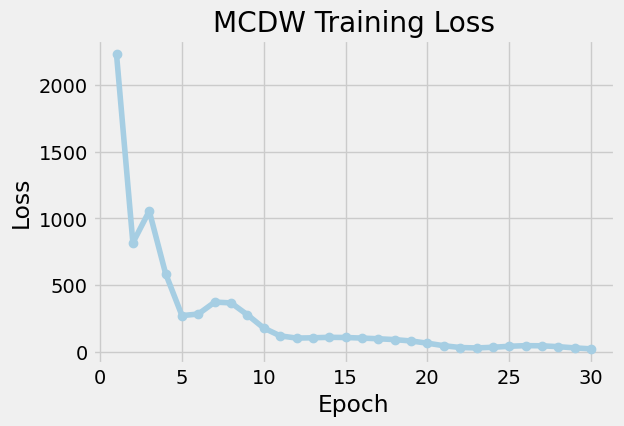

In [ ]:
selector.fit(X_train, treatment_train, y_train)

In [ ]:
importance = selector.get_feature_importance()

In [ ]:
top_50_features = selector.select_top_k(50)

In [ ]:
top_30_features = selector.select_top_k(30)

In [ ]:
top_80_features = selector.select_top_k(80)

In [ ]:
top_50_features

['sale_count_12m_g49',
 'cheque_count_6m_g58',
 'cheque_count_6m_g25',
 'cheque_count_12m_g58',
 'promo_share_15d',
 'crazy_purchases_cheque_count_1m',
 'cheque_count_6m_g79',
 'k_var_disc_share_3m_g48',
 'k_var_disc_share_3m_g41',
 'response_viber',
 'children',
 'k_var_count_per_cheque_3m_g24',
 'cheque_count_3m_g52',
 'cheque_count_12m_g25',
 'food_share_15d',
 'k_var_sku_price_1m_g44',
 'k_var_sku_price_3m_g54',
 'cheque_count_3m_g45',
 'k_var_sku_price_6m_g26',
 'k_var_sku_price_1m_g27',
 'cheque_count_12m_g20',
 'k_var_sku_price_3m_g48',
 'sale_count_6m_g57',
 'cheque_count_6m_g52',
 'k_var_sku_price_15d_g34',
 'cheque_count_6m_g20',
 'k_var_disc_share_1m_g24',
 'crazy_purchases_goods_count_6m',
 'k_var_disc_share_3m_g49',
 'k_var_sku_price_3m_g27',
 'cheque_count_12m_g46',
 'cheque_count_6m_g33',
 'k_var_sku_price_3m_g34',
 'k_var_count_per_cheque_15d_g24',
 'main_format',
 'k_var_disc_share_6m_g34',
 'sale_count_12m_g57',
 'k_var_sku_price_1m_g34',
 'cheque_count_12m_g79',
 'cr

In [ ]:
model_t_v6, model_c_v6, uplift_pred_train_v6, auuc_train_v6, study = train_tlearner(BASE_MODEL, X_train, treatment_train, y_train, 
                                                                                    X_val, treatment_val, y_val,
                                                                                    top_30_features)

[I 2026-03-10 07:35:39,177] A new study created in memory with name: no-name-9e0a6397-eaf7-4186-9e4f-5aa841f6ef89
[I 2026-03-10 07:37:07,682] Trial 8 finished with value: 0.7203199281972833 and parameters: {'depth_c': 5, 'learning_rate_c': 0.2222372924775685, 'iterations_c': 1172, 'l2_leaf_reg_c': 6.880113934653967, 'bagging_temperature_c': 3.9949913775257775, 'random_strength_c': 7.2524248134578375, 'min_data_in_leaf_c': 98, 'depth_t': 6, 'learning_rate_t': 0.034554437628110564, 'iterations_t': 568, 'l2_leaf_reg_t': 12.119302295767191, 'bagging_temperature_t': 9.308954786301054, 'random_strength_t': 5.726372893603436, 'min_data_in_leaf_t': 52}. Best is trial 8 with value: 0.7203199281972833.


AUUC: 0.7203199281972833


[I 2026-03-10 07:37:14,044] Trial 7 finished with value: 0.4215264226873276 and parameters: {'depth_c': 6, 'learning_rate_c': 0.06910218299397486, 'iterations_c': 345, 'l2_leaf_reg_c': 5.2071796394332885, 'bagging_temperature_c': 7.705547915021577, 'random_strength_c': 1.8325188849078278, 'min_data_in_leaf_c': 88, 'depth_t': 9, 'learning_rate_t': 0.06999404784580579, 'iterations_t': 679, 'l2_leaf_reg_t': 9.394823366165655, 'bagging_temperature_t': 0.03849523241028385, 'random_strength_t': 8.197092941750658, 'min_data_in_leaf_t': 43}. Best is trial 8 with value: 0.7203199281972833.


AUUC: 0.4215264226873276


[I 2026-03-10 07:37:22,144] Trial 0 finished with value: 0.4983114422980638 and parameters: {'depth_c': 9, 'learning_rate_c': 0.01847624287536004, 'iterations_c': 965, 'l2_leaf_reg_c': 14.816479070513767, 'bagging_temperature_c': 0.7093649971862581, 'random_strength_c': 5.0179496293529, 'min_data_in_leaf_c': 75, 'depth_t': 4, 'learning_rate_t': 0.03051903132755589, 'iterations_t': 607, 'l2_leaf_reg_t': 11.652178146219226, 'bagging_temperature_t': 3.5675996977206115, 'random_strength_t': 2.5522955766321695, 'min_data_in_leaf_t': 62}. Best is trial 8 with value: 0.7203199281972833.


...

AUUC: 0.7458931240874944
AUUC: 0.6435132718504364


[I 2026-03-10 07:44:55,206] Trial 48 finished with value: 0.6397618033685598 and parameters: {'depth_c': 7, 'learning_rate_c': 0.10251334186269428, 'iterations_c': 994, 'l2_leaf_reg_c': 18.434735684608476, 'bagging_temperature_c': 0.9897981150074876, 'random_strength_c': 5.27960401021709, 'min_data_in_leaf_c': 39, 'depth_t': 8, 'learning_rate_t': 0.017833072644555917, 'iterations_t': 1073, 'l2_leaf_reg_t': 7.187100472891835, 'bagging_temperature_t': 3.5383620555906683, 'random_strength_t': 5.5592586968949025, 'min_data_in_leaf_t': 35}. Best is trial 28 with value: 0.8138822798778959.


AUUC: 0.6397618033685598


[I 2026-03-10 07:44:55,985] Trial 45 finished with value: 0.6041526050927151 and parameters: {'depth_c': 7, 'learning_rate_c': 0.28517022362487743, 'iterations_c': 1392, 'l2_leaf_reg_c': 7.786764793339524, 'bagging_temperature_c': 8.371852772361544, 'random_strength_c': 5.131290266130103, 'min_data_in_leaf_c': 41, 'depth_t': 8, 'learning_rate_t': 0.018808236500427445, 'iterations_t': 1113, 'l2_leaf_reg_t': 3.4197691040821456, 'bagging_temperature_t': 3.9204892051978137, 'random_strength_t': 5.490606418479639, 'min_data_in_leaf_t': 10}. Best is trial 28 with value: 0.8138822798778959.


AUUC: 0.6041526050927151
AUUC: 6.706029397271725


In [ ]:
uplift_pred_test_v6, auuc_test_v6 = get_uplift(model_t_v6, model_c_v6, X_test, treatment_test, y_test, top_30_features)

AUUC: 0.5723519830711373


In [ ]:
model_t_v7, model_c_v7, uplift_pred_train_v7, auuc_train_v7, study = train_tlearner(BASE_MODEL, X_train, treatment_train, y_train, 
                                                                                    X_val, treatment_val, y_val,
                                                                                    top_50_features)

[I 2026-03-10 07:45:17,133] A new study created in memory with name: no-name-072cdfc2-11fb-4127-afc6-e4475a2eb428
[I 2026-03-10 07:47:17,340] Trial 3 finished with value: 0.7254121098543415 and parameters: {'depth_c': 6, 'learning_rate_c': 0.1734841211061431, 'iterations_c': 1239, 'l2_leaf_reg_c': 6.06713134913039, 'bagging_temperature_c': 0.7273578740693243, 'random_strength_c': 3.710198041620486, 'min_data_in_leaf_c': 68, 'depth_t': 4, 'learning_rate_t': 0.04867053139923448, 'iterations_t': 672, 'l2_leaf_reg_t': 19.373576023704576, 'bagging_temperature_t': 7.7722234706308555, 'random_strength_t': 4.1532245714506235, 'min_data_in_leaf_t': 18}. Best is trial 3 with value: 0.7254121098543415.


AUUC: 0.7254121098543415


[I 2026-03-10 07:47:18,054] Trial 0 finished with value: 0.6547078354241995 and parameters: {'depth_c': 4, 'learning_rate_c': 0.02929545264516856, 'iterations_c': 1174, 'l2_leaf_reg_c': 10.500939636344635, 'bagging_temperature_c': 7.00633310377142, 'random_strength_c': 2.993596650400683, 'min_data_in_leaf_c': 93, 'depth_t': 5, 'learning_rate_t': 0.0878851174227766, 'iterations_t': 762, 'l2_leaf_reg_t': 19.514680800610144, 'bagging_temperature_t': 9.932886775634547, 'random_strength_t': 8.69680663252916, 'min_data_in_leaf_t': 66}. Best is trial 3 with value: 0.7254121098543415.


AUUC: 0.6547078354241995


[I 2026-03-10 07:47:26,264] Trial 11 finished with value: 0.5914400744134138 and parameters: {'depth_c': 8, 'learning_rate_c': 0.019093223507685754, 'iterations_c': 605, 'l2_leaf_reg_c': 10.768720523871576, 'bagging_temperature_c': 2.2604149624727787, 'random_strength_c': 0.8829917277580024, 'min_data_in_leaf_c': 27, 'depth_t': 9, 'learning_rate_t': 0.09604108846240249, 'iterations_t': 573, 'l2_leaf_reg_t': 1.5738732780658249, 'bagging_temperature_t': 4.08772859247925, 'random_strength_t': 1.6989491749272134, 'min_data_in_leaf_t': 23}. Best is trial 3 with value: 0.7254121098543415.


...

AUUC: 0.6808970633379388


[I 2026-03-10 07:58:03,691] Trial 48 finished with value: 0.6847634266128787 and parameters: {'depth_c': 8, 'learning_rate_c': 0.08617013983132647, 'iterations_c': 938, 'l2_leaf_reg_c': 2.844590061623391, 'bagging_temperature_c': 6.082933093725032, 'random_strength_c': 8.464899238878088, 'min_data_in_leaf_c': 99, 'depth_t': 6, 'learning_rate_t': 0.022582823393860314, 'iterations_t': 1278, 'l2_leaf_reg_t': 18.9080067442975, 'bagging_temperature_t': 7.394239470306683, 'random_strength_t': 7.87968692946565, 'min_data_in_leaf_t': 88}. Best is trial 41 with value: 0.8630062531526497.


AUUC: 0.6847634266128787


[I 2026-03-10 07:58:07,415] Trial 49 finished with value: 0.7622285192127252 and parameters: {'depth_c': 8, 'learning_rate_c': 0.09263391793888821, 'iterations_c': 940, 'l2_leaf_reg_c': 2.802516518381607, 'bagging_temperature_c': 5.996014498994465, 'random_strength_c': 8.558548629949785, 'min_data_in_leaf_c': 53, 'depth_t': 6, 'learning_rate_t': 0.02174334591783371, 'iterations_t': 1267, 'l2_leaf_reg_t': 12.523123100847368, 'bagging_temperature_t': 8.891500382794929, 'random_strength_t': 7.360338883398068, 'min_data_in_leaf_t': 60}. Best is trial 41 with value: 0.8630062531526497.


AUUC: 0.7622285192127252
AUUC: 6.768483175498673


In [ ]:
uplift_pred_test_v7, auuc_test_v7 = get_uplift(model_t_v7, model_c_v7, X_test, treatment_test, y_test, top_50_features)

AUUC: 0.4082072473339162


In [ ]:
# 128 hidden_dim - 0.5173856389513593 test

In [ ]:
model_t_v8, model_c_v8, uplift_pred_train_v8, auuc_train_v8, study = train_tlearner(BASE_MODEL, X_train, treatment_train, y_train, 
                                                                                    X_val, treatment_val, y_val,
                                                                                    top_80_features)

[I 2026-03-10 07:58:31,217] A new study created in memory with name: no-name-e1701b5d-3f94-438b-bc6f-78f6374ed530
[I 2026-03-10 08:00:36,103] Trial 9 finished with value: 0.6819991103838097 and parameters: {'depth_c': 5, 'learning_rate_c': 0.010096893265700789, 'iterations_c': 1311, 'l2_leaf_reg_c': 10.494993461768653, 'bagging_temperature_c': 2.628899849757201, 'random_strength_c': 2.860341733126881, 'min_data_in_leaf_c': 59, 'depth_t': 4, 'learning_rate_t': 0.013364820098695393, 'iterations_t': 480, 'l2_leaf_reg_t': 19.180625758009672, 'bagging_temperature_t': 2.3256849950355427, 'random_strength_t': 2.9163389492104788, 'min_data_in_leaf_t': 66}. Best is trial 9 with value: 0.6819991103838097.


AUUC: 0.6819991103838097


[I 2026-03-10 08:01:23,969] Trial 11 finished with value: 0.6621572012173849 and parameters: {'depth_c': 5, 'learning_rate_c': 0.015215063513345584, 'iterations_c': 314, 'l2_leaf_reg_c': 5.338242655754382, 'bagging_temperature_c': 7.708014915028897, 'random_strength_c': 9.944525628624135, 'min_data_in_leaf_c': 67, 'depth_t': 7, 'learning_rate_t': 0.0191292224076983, 'iterations_t': 986, 'l2_leaf_reg_t': 3.956750764844848, 'bagging_temperature_t': 3.586885390020176, 'random_strength_t': 7.966099226569442, 'min_data_in_leaf_t': 71}. Best is trial 9 with value: 0.6819991103838097.


AUUC: 0.6621572012173849


[I 2026-03-10 08:02:05,974] Trial 5 finished with value: 0.4679197601346505 and parameters: {'depth_c': 4, 'learning_rate_c': 0.04667878839019229, 'iterations_c': 503, 'l2_leaf_reg_c': 18.042307146695055, 'bagging_temperature_c': 4.9515457651310735, 'random_strength_c': 1.135558398767763, 'min_data_in_leaf_c': 65, 'depth_t': 5, 'learning_rate_t': 0.2272574170496718, 'iterations_t': 1446, 'l2_leaf_reg_t': 18.102199448659004, 'bagging_temperature_t': 9.781730772652551, 'random_strength_t': 7.756595376741627, 'min_data_in_leaf_t': 75}. Best is trial 9 with value: 0.6819991103838097.


...

AUUC: 0.5952014987994263


[I 2026-03-10 08:14:02,523] Trial 45 finished with value: 0.6575729888044237 and parameters: {'depth_c': 10, 'learning_rate_c': 0.16522646204865907, 'iterations_c': 576, 'l2_leaf_reg_c': 15.641869052330918, 'bagging_temperature_c': 1.4045441811796604, 'random_strength_c': 2.568011985094662, 'min_data_in_leaf_c': 74, 'depth_t': 8, 'learning_rate_t': 0.022825319089063736, 'iterations_t': 1086, 'l2_leaf_reg_t': 12.862482040897698, 'bagging_temperature_t': 8.603151189936858, 'random_strength_t': 1.8990659865431296, 'min_data_in_leaf_t': 27}. Best is trial 30 with value: 0.7764828344965905.


AUUC: 0.6575729888044237


[I 2026-03-10 08:14:05,002] Trial 46 finished with value: 0.6392629825432152 and parameters: {'depth_c': 10, 'learning_rate_c': 0.16826048366984053, 'iterations_c': 795, 'l2_leaf_reg_c': 15.76361635406108, 'bagging_temperature_c': 1.3485619233910027, 'random_strength_c': 2.4841049298036806, 'min_data_in_leaf_c': 85, 'depth_t': 6, 'learning_rate_t': 0.02315094942284966, 'iterations_t': 1063, 'l2_leaf_reg_t': 13.223669495774372, 'bagging_temperature_t': 8.708280902654787, 'random_strength_t': 5.008877557509644, 'min_data_in_leaf_t': 27}. Best is trial 30 with value: 0.7764828344965905.


AUUC: 0.6392629825432152
AUUC: 10.490218351719099


In [ ]:
uplift_pred_test_v8, auuc_test_v8 = get_uplift(model_t_v8, model_c_v8, X_test, treatment_test, y_test, top_80_features)

AUUC: 0.4985483007153962


### Вывод

|Статья |Число признаков| AUUC train |AUUC test |
|-------|-----------|----------|-------|
Customer feature selection from high‐dimensional bank direct marketing data for uplift modeling| 48 |  6.72| 0.74 |
Doubly Robust Adaptive LASSO for Effect| 184 |  6.74| 0.49|
A Non-parametric Bayesian Approach for Uplift Discretization and Feature Selection| 12 |  7.03| 0.81|
A Non-parametric Bayesian Approach for Uplift Discretization and Feature Selection| 50 |  5.97| 0.46|
Robustness-enhanced Uplift Modeling with Adversarial Feature Desensitization| 50 |  2.6| 0.50|
Multihead Causal Distilling Weighting Is All You Need for Uplift Modeling| 30 | 6.70| 0.57|
Multihead Causal Distilling Weighting Is All You Need for Uplift Modeling| 50 | 6.77| 0.41|
Multihead Causal Distilling Weighting Is All You Need for Uplift Modeling| 80 | 10.49| 0.50|

Наилучший результат показал эксперимент из статьи A Non-parametric Bayesian Approach for Uplift Discretization and Feature Selection с 12 признаками    